In [ ]:
# ============================================================
# Hücre 1: Kütüphane Kurulumu (LightGlue Eklenmiştir)
# ============================================================
!pip install faiss-cpu folium scikit-learn -q
!pip install git+https://github.com/cvg/LightGlue.git -q
print("✅ Tüm kütüphaneler kuruldu (LightGlue dahil).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 131.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.2 MB/s eta 0:00:00
✅ Tüm kütüphaneler kuruldu (LightGlue dahil).


In [ ]:
# ============================================================
# Hücre 2: Import'lar ve Konfigürasyon
# ============================================================
import os, json, random, zipfile, shutil, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import folium

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import faiss

# LightGlue importları
from lightglue import LightGlue, ALIKED, viz2d
from lightglue.utils import load_image, rbd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DRIVE_ZIP        = "/content/drive/My Drive/kirsehir_data.zip"
LOCAL_ROOT       = "/content/kirsehir_data"
OUTPUT_DIR       = "/content/drive/My Drive/Kirsehir_VPR_DINOv2_v4_Final"
DRIVE_MODEL_PATH = os.path.join(OUTPUT_DIR, "dinov2_kirsehir_v4_final.pth")
LOCAL_MODEL_PATH = "/content/model_weights.pth"

MODEL_NAME    = "dinov2_vitb14"
OUTFEATURES   = 512
IMG_SIZE      = 518
BATCH_SIZE    = 32
NUM_WORKERS   = 2
RERANK_TOP_K  = 20
GRID_SIZE     = 0.002

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Konfigürasyon Tamam. Cihaz: {DEVICE}")

✅ Konfigürasyon Tamam. Cihaz: cuda


In [ ]:
# ============================================================
# Hücre 3: Veri Yükleme ve Bölme (Aynı Standart Test Spliti)
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

if not os.path.exists(LOCAL_ROOT):
    LOCAL_ZIP = "/content/kirsehir_data.zip"
    shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as zf:
        zf.extractall(LOCAL_ROOT)
    os.remove(LOCAL_ZIP)

entries = os.listdir(LOCAL_ROOT)
if len(entries) == 1 and os.path.isdir(os.path.join(LOCAL_ROOT, entries[0])):
    LOCAL_ROOT = os.path.join(LOCAL_ROOT, entries[0])

def extract_lat_lon_heading(filepath):
    parts = os.path.splitext(os.path.basename(filepath))[0].split("_")
    try: return float(parts[0]), float(parts[1]), float(parts[2].replace("h", "") if len(parts)>2 else "0")
    except: return None, None, None

all_images =[]
for street_name in sorted(os.listdir(LOCAL_ROOT)):
    street_path = os.path.join(LOCAL_ROOT, street_name)
    if not os.path.isdir(street_path) or street_name == "model": continue
    for fname in sorted(os.listdir(street_path)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")): continue
        lat, lon, hdg = extract_lat_lon_heading(os.path.join(street_path, fname))
        if lat is not None:
            all_images.append({
                "filepath": os.path.join(street_path, fname), "street": street_name,
                "lat": lat, "lon": lon, "heading": hdg,
                "point_id": f"{lat:.6f}_{lon:.6f}",
                "block_id": f"{int(lat/GRID_SIZE)}_{int(lon/GRID_SIZE)}"
            })

df_all = pd.DataFrame(all_images).sort_values(by=["point_id", "heading"])
unique_blocks = df_all["block_id"].unique().tolist()
random.shuffle(unique_blocks)

test_blocks  = set(unique_blocks[int(len(unique_blocks) * 0.70):])
df_test = df_all[df_all["block_id"].isin(test_blocks)].copy()
valid_points = df_test['point_id'].value_counts()[df_test['point_id'].value_counts() >= 2].index
df_test = df_test[df_test['point_id'].isin(valid_points)]

df_query = df_test.groupby("point_id").tail(1).reset_index(drop=True)
df_db = df_test[~df_test["filepath"].isin(set(df_query["filepath"]))].reset_index(drop=True)

print(f"🗺️ Harita (DB) Boyutu: {len(df_db)} | 🔍 Sorgu (Query) Boyutu: {len(df_query)}")

Mounted at /content/drive
🗺️ Harita (DB) Boyutu: 6060 | 🔍 Sorgu (Query) Boyutu: 2020


In [ ]:
# ============================================================
# Hücre 4: DINOv2 Modelini Yükleme (Drive'dan Kopyalayarak)
# ============================================================
class GeMPooling(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p).mean(dim=1).pow(1.0 / self.p)

class VPRDINOv2(nn.Module):
    def __init__(self, backbone_name, out_dim):
        super().__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', backbone_name)
        self.gem = GeMPooling(p=3)
        embed_dim = self.backbone.embed_dim
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.BatchNorm1d(embed_dim),
            nn.ReLU(), nn.Linear(embed_dim, out_dim)
        )
    def forward(self, x):
        return nn.functional.normalize(self.head(self.gem(self.backbone.forward_features(x)['x_norm_patchtokens'])), p=2, dim=1)

model = VPRDINOv2(MODEL_NAME, OUTFEATURES).to(DEVICE)

if os.path.exists(DRIVE_MODEL_PATH):
    print(f"⏳ Ağırlıklar Drive'dan kopyalanıyor...\nKaynak: {DRIVE_MODEL_PATH}")
    shutil.copy2(DRIVE_MODEL_PATH, LOCAL_MODEL_PATH)
    model.load_state_dict(torch.load(LOCAL_MODEL_PATH, map_location=DEVICE))
    print("✅ Model ağırlıkları başarıyla yüklendi! Eğitim atlandı.")
else:
    raise FileNotFoundError("❌ Drive'da model ağırlıkları bulunamadı! Lütfen yolu kontrol edin.")

model.eval()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 347MB/s]


⏳ Ağırlıklar Drive'dan kopyalanıyor...
Kaynak: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v4_Final/dinov2_kirsehir_v4_final.pth
✅ Model ağırlıkları başarıyla yüklendi! Eğitim atlandı.


VPRDINOv2(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
        (ls2): LayerScale()
        (drop_path2): Ident

In [ ]:
# ============================================================
# Hücre 5: DINOv2 ile Global Feature Extraction (FAISS)
# ============================================================
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class StandardVPRDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.df.iloc[idx]["filepath"]).convert("RGB")), idx

@torch.no_grad()
def extract_embeddings(df, desc="Emb"):
    loader = DataLoader(StandardVPRDataset(df, eval_transform), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    embs =[]
    for imgs, _ in tqdm(loader, desc=desc):
        embs.append(model(imgs.to(DEVICE)).cpu().numpy())
    return np.concatenate(embs, axis=0)

db_embeddings = extract_embeddings(df_db, "DB Emb (Harita Çıkarılıyor)")
query_embeddings = extract_embeddings(df_query, "Query Emb (Sorgu Çıkarılıyor)")

faiss.normalize_L2(db_embeddings)
faiss_index = faiss.IndexFlatIP(OUTFEATURES)
faiss_index.add(db_embeddings.astype(np.float32))
db_meta = df_db.to_dict("records")
print("✅ FAISS İndeksi hazırlandı.")

Query Emb (Sorgu Çıkarılıyor): 100%|██████████| 64/64 [00:14<00:00,  4.54it/s]

✅ FAISS İndeksi hazırlandı.


In [ ]:
# ============================================================
# Hücre 6: LightGlue Kurulumu ve İki Aşamalı Re-Ranking Fonksiyonu
# ============================================================
lg_extractor = ALIKED(max_num_keypoints=1024).eval().to(DEVICE)
lg_matcher = LightGlue(features='aliked').eval().to(DEVICE)

def rerank_with_lightglue(query_path, top_k_candidates):
    img0 = load_image(query_path).to(DEVICE)
    feats0 = lg_extractor.extract(img0)

    reranked_results =[]

    for rank, cand in enumerate(top_k_candidates):
        img1 = load_image(cand["filepath"]).to(DEVICE)
        feats1 = lg_extractor.extract(img1)

        matches01 = lg_matcher({"image0": feats0, "image1": feats1})
        feats0_clean, feats1_clean, matches01_clean =[rbd(x) for x in [feats0, feats1, matches01]]

        num_matches = len(matches01_clean['matches'])

        reranked_results.append({
            "original_rank": rank + 1,
            "filepath": cand["filepath"],
            "street": cand["street"],
            "lat": cand["lat"], "lon": cand["lon"],
            "num_matches": num_matches,
            "dino_score": cand["dino_score"]
        })

        del img1, feats1, matches01
        torch.cuda.empty_cache()

    reranked_results = sorted(reranked_results, key=lambda x: x["num_matches"], reverse=True)
    return reranked_results, feats0

print("✅ LightGlue Re-Ranking Modülleri Yüklendi.")

Downloading: "https://github.com/Shiaoming/ALIKED/raw/main/models/aliked-n16.pth" to /root/.cache/torch/hub/checkpoints/aliked-n16.pth


100%|██████████| 2.61M/2.61M [00:00<00:00, 88.7MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth" to /root/.cache/torch/hub/checkpoints/aliked_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 80.7MB/s]

✅ LightGlue Re-Ranking Modülleri Yüklendi.



🔍 LİGHTGLUE RE-RANKING DEMOSU (1 ÖRNEK)
Sorgu: 2320. Sokak - DINOv2 Top-20 sonucu LightGlue ile taranıyor...

📊 SONUÇ:
DINOv2 İlk Tahmin Hatası : 0.0 m (Güven skoru: 0.89)
LightGlue Yeni Tahmin Hatası: 1471.2 m (Kilit Nokta Eşleşmesi: 77)


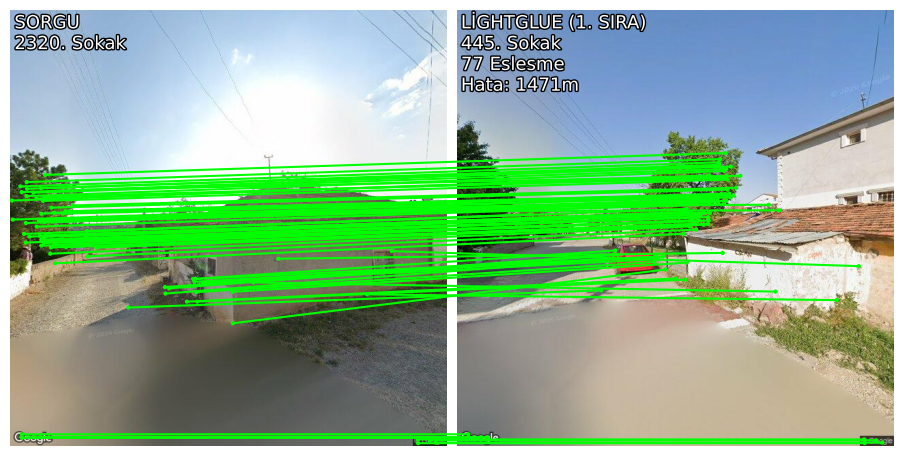

In [ ]:
# ============================================================
# Hücre 7: Görselleştirilmiş Örnek Eşleştirme (Demo) - DÜZELTİLDİ
# ============================================================
print(f"\n{'='*60}\n🔍 LİGHTGLUE RE-RANKING DEMOSU (1 ÖRNEK)\n{'='*60}")

demo_idx = random.randint(0, len(df_query)-1)
q_row = df_query.iloc[demo_idx]

# 1. Aşama: DINOv2 FAISS Araması
faiss.normalize_L2(query_embeddings)
dists, idxs = faiss_index.search(query_embeddings[demo_idx:demo_idx+1].astype(np.float32), RERANK_TOP_K)

dino_candidates =[]
for i in range(RERANK_TOP_K):
    match = db_meta[idxs[0][i]].copy()
    match["dino_score"] = float(dists[0][i])
    dino_candidates.append(match)

# 2. Aşama: LightGlue ile Yeniden Sıralama
print(f"Sorgu: {q_row['street']} - DINOv2 Top-20 sonucu LightGlue ile taranıyor...")
reranked_results, feats0 = rerank_with_lightglue(q_row["filepath"], dino_candidates)

best_match = reranked_results[0]
dino_best = dino_candidates[0]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2, dp, dl = map(math.radians,[lat1, lat2, lat2-lat1, lon2-lon1])
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

dino_err = haversine(q_row["lat"], q_row["lon"], dino_best["lat"], dino_best["lon"])
lg_err = haversine(q_row["lat"], q_row["lon"], best_match["lat"], best_match["lon"])

print(f"\n📊 SONUÇ:")
print(f"DINOv2 İlk Tahmin Hatası : {dino_err:.1f} m (Güven skoru: {dino_best['dino_score']:.2f})")
print(f"LightGlue Yeni Tahmin Hatası: {lg_err:.1f} m (Kilit Nokta Eşleşmesi: {best_match['num_matches']})")

img0 = load_image(q_row["filepath"])
img1 = load_image(best_match["filepath"])

feats1 = lg_extractor.extract(img1.to(DEVICE))
matches01 = lg_matcher({"image0": feats0, "image1": feats1})
feats0_c, feats1_c, matches01_c =[rbd(x) for x in[feats0, feats1, matches01]]

kpts0, kpts1, matches = feats0_c["keypoints"], feats1_c["keypoints"], matches01_c["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

viz2d.plot_images([img0, img1]) # ax=ax kaldırıldı, figür otomatik oluşur
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=1.5)
viz2d.add_text(0, f"SORGU\n{q_row['street'][:20]}", fs=13)
viz2d.add_text(1, f"LİGHTGLUE (1. SIRA)\n{best_match['street'][:20]}\n{best_match['num_matches']} Eslesme\nHata: {lg_err:.0f}m", fs=13)
plt.show()

📊 SINGLE-IMAGE RECALL@K — SADECE DINOv2 v4 (Metric Learning)
   Sokak İsmi Doğruluğu : 74.70%

📈 DINOv2 v4 GPS Hata Özeti:
   Ortanca (Median) : 8.2 metre
   Ortalama (Mean)  : 179.6 metre

📏 Mesafe Bazlı Başarı (Recall@1):
   < 25 m:  61.73%
   < 50 m:  71.88%
   < 100m:  81.24%
   < 500m:  91.39%


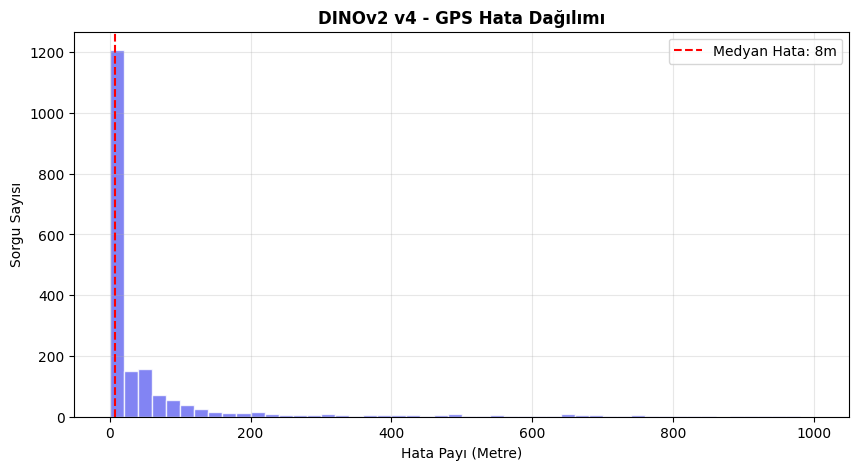

In [ ]:
# ============================================================
# Hücre 8: Sadece DINOv2 v4'ün Gerçek Başarısı (Tüm Set Testi)
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2, dp, dl = map(math.radians, [lat1, lat2, lat2-lat1, lon2-lon1])
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

print(f"{'='*65}")
print(f"📊 SINGLE-IMAGE RECALL@K — SADECE DINOv2 v4 (Metric Learning)")
print(f"{'='*65}")

faiss.normalize_L2(query_embeddings)
K_MAX = 10
dists_all, idxs_all = faiss_index.search(query_embeddings.astype(np.float32), K_MAX)

K_vals =[1, 5, 10]
errors_single =[]
correct_street = 0

for i, q_row in df_query.iterrows():
    q_lat, q_lon = q_row["lat"], q_row["lon"]
    best_match = db_meta[idxs_all[i, 0]]

    dist = haversine(q_lat, q_lon, best_match["lat"], best_match["lon"])
    errors_single.append(dist)

    if best_match["street"] == q_row["street"]:
        correct_street += 1

errors_single = np.array(errors_single)

print(f"   Sokak İsmi Doğruluğu : {correct_street/len(df_query)*100:.2f}%")
print(f"\n📈 DINOv2 v4 GPS Hata Özeti:")
print(f"   Ortanca (Median) : {np.median(errors_single):.1f} metre")
print(f"   Ortalama (Mean)  : {errors_single.mean():.1f} metre")

print(f"\n📏 Mesafe Bazlı Başarı (Recall@1):")
for t in[25, 50, 100, 500]:
    acc = (errors_single <= t).mean() * 100
    print(f"   < {t:<3}m: {acc:>6.2f}%")

# Hata Dağılımı Histogramı
plt.figure(figsize=(10, 5))
plt.hist(errors_single, bins=50, range=(0, 1000), color="#6366f1", edgecolor="white", alpha=0.8)
plt.axvline(x=np.median(errors_single), color="red", linestyle="--", label=f"Medyan Hata: {np.median(errors_single):.0f}m")
plt.title("DINOv2 v4 - GPS Hata Dağılımı", fontweight="bold")
plt.xlabel("Hata Payı (Metre)")
plt.ylabel("Sorgu Sayısı")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# Hücre 9: Manuel Fotoğraf Yükleyip Test Etme
# ============================================================
from google.colab import files
import folium
from IPython.display import display

print(f"\n{'='*60}\n📸 KENDİ FOTOĞRAFINIZLA TEST EDİN\n{'='*60}")
print("Lütfen bir sokak veya bina fotoğrafı yükleyin (jpg, jpeg, png):")
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"\n✅ '{uploaded_filename}' başarıyla yüklendi. İşleniyor...")

    # 1. Aşama: DINOv2 Embedding Çıkarımı ve FAISS Araması
    img_pil = Image.open(uploaded_filename).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        query_emb = model(img_tensor).cpu().numpy()

    faiss.normalize_L2(query_emb)
    dists, idxs = faiss_index.search(query_emb.astype(np.float32), RERANK_TOP_K)

    dino_candidates = []
    for i in range(RERANK_TOP_K):
        match = db_meta[idxs[0][i]].copy()
        match["dino_score"] = float(dists[0][i])
        dino_candidates.append(match)

    dino_best = dino_candidates[0]
    print(f"🔍 DINOv2 İlk Tahmin: {dino_best['street']} (Skor: {dino_best['dino_score']:.2f})")

    # 2. Aşama: LightGlue ile Yeniden Sıralama (Re-Ranking)
    print("⚡ LightGlue ile Top-20 aday yeniden sıralanıyor...")
    reranked_results, feats0 = rerank_with_lightglue(uploaded_filename, dino_candidates)
    best_match = reranked_results[0]

    print(f"\n🏆 EN İYİ EŞLEŞME (LİGHTGLUE SONRASI):")
    print(f"   Sokak: {best_match['street']}")
    print(f"   Kilit Nokta Eşleşmesi: {best_match['num_matches']}")
    print(f"   GPS: {best_match['lat']:.6f}, {best_match['lon']:.6f}")

    # Görselleştirme (Eşleşen Kilit Noktalar)
    img0 = load_image(uploaded_filename)
    img1 = load_image(best_match["filepath"])

    feats1 = lg_extractor.extract(img1.to(DEVICE))
    matches01 = lg_matcher({"image0": feats0, "image1": feats1})
    feats0_c, feats1_c, matches01_c = [rbd(x) for x in [feats0, feats1, matches01]]

    kpts0, kpts1, matches = feats0_c["keypoints"], feats1_c["keypoints"], matches01_c["matches"]
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

    viz2d.plot_images([img0, img1])
    viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=1.5)
    viz2d.add_text(0, "YÜKLENEN FOTOĞRAF", fs=13)
    viz2d.add_text(1, f"EŞLEŞEN: {best_match['street'][:20]}\n{best_match['num_matches']} Eşleşme", fs=13)
    plt.show()

    # Harita üzerinde konumu göster
    print("\n🗺️ Tahmin Edilen Konum Haritası:")
    m = folium.Map(location=[best_match["lat"], best_match["lon"]], zoom_start=17)
    folium.Marker(
        [best_match["lat"], best_match["lon"]],
        popup=f"{best_match['street']}\nMatch: {best_match['num_matches']}",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    display(m)

else:
    print("❌ Dosya yüklenmedi.")



📸 KENDİ FOTOĞRAFINIZLA TEST EDİN
Lütfen bir sokak veya bina fotoğrafı yükleyin (jpg, jpeg, png):


Saving Screenshot 2026-03-19 111458.png to Screenshot 2026-03-19 111458.png

✅ 'Screenshot 2026-03-19 111458.png' başarıyla yüklendi. İşleniyor...


NameError: name 'Image' is not defined